# Crimes by District OPENDOSM prediction using Random Forest Regressor

## Goal: Train a Random Forest Regression model to predict the Probability of Crimes occuring at a specific district in the future

### 1. Data At A Glance

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

crime_file_path = "crime_district.csv"
crime_df = pd.read_csv(crime_file_path)
crime_df.describe(include = "all") #to include every available variables in the dataset

,state,district,category,type,date,crimes
count,19152,19152,19152,19152,19152,19152.000000
unique,15,160,2,13,8,NaN
top,Sarawak,All,assault,all,2016-01-01,NaN
freq,3248,1680,10944,2736,2394,NaN
mean,NaN,NaN,NaN,NaN,NaN,189.728018
std,NaN,NaN,NaN,NaN,NaN,1590.813293
min,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,1.000000
50%,NaN,NaN,NaN,NaN,NaN,12.000000
75%,NaN,NaN,NaN,NaN,NaN,66.000000


In [ ]:
crime_df.columns

Index(['state', 'district', 'category', 'type', 'date', 'crimes'], dtype='str')

In [ ]:
crime_df['date'] = pd.to_datetime(crime_df['date'])
crime_df['date'].min(), crime_df['date'].max()

(Timestamp('2016-01-01 00:00:00'), Timestamp('2023-01-01 00:00:00'))

In [ ]:
crime_df['state'].unique()

<StringArray>
[         'Malaysia',             'Johor',             'Kedah',
          'Kelantan',            'Melaka',   'Negeri Sembilan',
            'Pahang',             'Perak',            'Perlis',
      'Pulau Pinang',             'Sabah',           'Sarawak',
          'Selangor',        'Terengganu', 'W.P. Kuala Lumpur']
Length: 15, dtype: str

In [ ]:
crime_df['district'].unique()

<StringArray>
[                'All',          'Batu Pahat',     'Iskandar Puteri',
 'Johor Bahru Selatan',   'Johor Bahru Utara',              'Kluang',
         'Kota Tinggi',           'Kulaijaya',              'Ledang',
             'Mersing',
 ...
             'Kemaman',    'Kuala Terengganu',              'Marang',
               'Setiu',         'Brickfields',              'Cheras',
          'Dang Wangi',              'Sentul',      'W.P. Putrajaya',
         'Wangsa Maju']
Length: 160, dtype: str

In [ ]:
crime_df['category'].unique()

<StringArray>
['assault', 'property']
Length: 2, dtype: str

In [ ]:
crime_df['type'].unique()

<StringArray>
[                     'all',           'causing_injury',
                   'murder',                     'rape',
       'robbery_gang_armed',     'robbery_gang_unarmed',
       'robbery_solo_armed',     'robbery_solo_unarmed',
                 'break_in',              'theft_other',
      'theft_vehicle_lorry',   'theft_vehicle_motorcar',
 'theft_vehicle_motorcycle']
Length: 13, dtype: str

Knowing the subcategories of the dataset columns gives a good idea on how to model, encode, and pick out the necessary features to predict the probability of crime

### 2. Data Cleaning

In [ ]:
crime_df.isna().sum() #check for total null values

state       0
district    0
category    0
type        0
date        0
crimes      0
dtype: int64

In [ ]:
crime_df.duplicated().sum() #check for duplicate rows if any

np.int64(0)

In [ ]:
#drop null rows if any
before_rows = crime_df.shape[0] 
crime_df = crime_df.dropna(axis=0)
after_rows = crime_df.shape[0]
print("Rows dropped:", before_rows - after_rows) 

Rows dropped: 0


In [ ]:
before_rows = crime_df.shape[0]

crime_df['district'] = crime_df['district'].str.lower()
crime_df['type'] = crime_df['type'].str.lower()

crime_df = crime_df[
    (crime_df['state'] != 'Malaysia') &
    (crime_df['type'] != 'all') &
    (crime_df['district'] != 'all')
]

print(f"Rows dropped: {before_rows - crime_df.shape[0]}")#removed malaysia since it represents national aggregate and crime type all for the same reason

Rows dropped: 4176


The dataset contains no null or duplicate values which makes our job and training the model a whole lot easier, this step is very important in training ML models to prevent underfitting and overfitting

### 3. Exploratory Data Analysis

#### 3.1 Dataset: Hierarchical Spatiotemporal - ChatGPT

In [ ]:
crime_df['crimes'].describe()

count    14976.000000
mean        40.431157
std        100.147130
min          0.000000
25%          0.000000
50%          6.000000
75%         31.000000
max       2263.000000
Name: crimes, dtype: float64

In [ ]:
crime_df.groupby('category')['crimes'].sum() #total number of crimes over the years, explains the number

category
assault     122659
property    482838
Name: crimes, dtype: int64

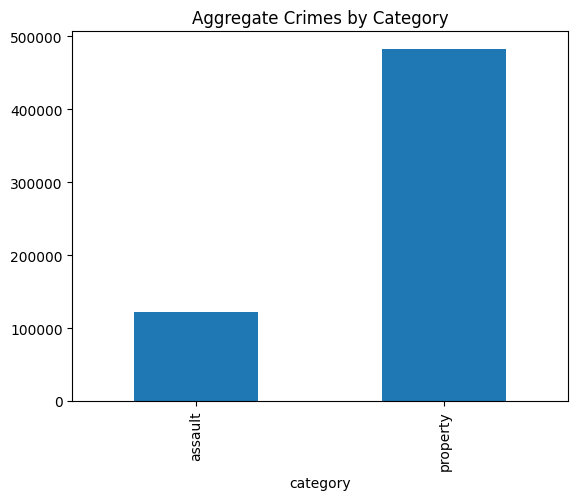

In [ ]:
crime_df.groupby('category')['crimes'].sum().plot(kind='bar')
plt.title("Aggregate Crimes by Category")
plt.show()

In [ ]:
crime_df['crimes'].skew()

np.float64(5.544939372788459)

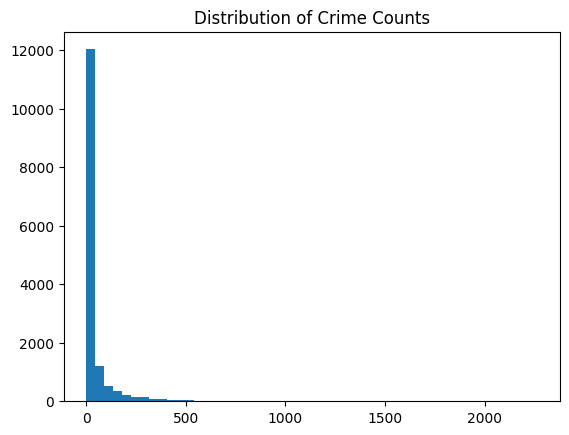

In [ ]:
import matplotlib.pyplot as plt

plt.hist(crime_df['crimes'], bins=50)
plt.title("Distribution of Crime Counts")
plt.show()

In [ ]:
crime_df.groupby('type')['crimes'].sum().sort_values(ascending=False)

type
theft_vehicle_motorcycle    162659
theft_other                 146660
break_in                    114734
theft_vehicle_motorcar       47281
robbery_gang_unarmed         44360
causing_injury               35608
robbery_solo_unarmed         26089
rape                         13868
theft_vehicle_lorry          11504
murder                        2462
robbery_gang_armed             205
robbery_solo_armed              67
Name: crimes, dtype: int64

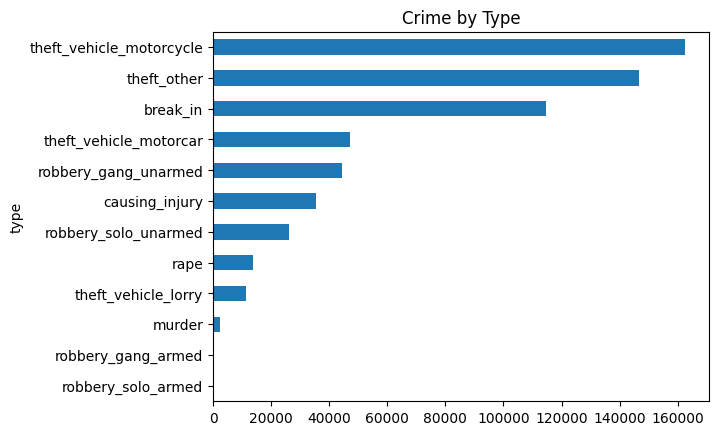

In [ ]:
crime_df.groupby('type')['crimes'].sum().sort_values().plot(kind='barh')
plt.title("Crime by Type")
plt.show()

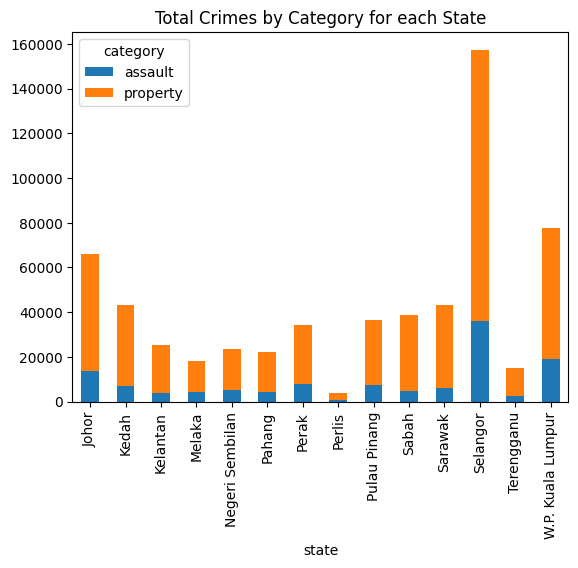

In [ ]:
pivot = crime_df.pivot_table(
    values='crimes',
    index='state',
    columns='category',
    aggfunc='sum'
)

pivot.plot(kind='bar', stacked=True)
plt.title("Total Crimes by Category for each State")
plt.show()

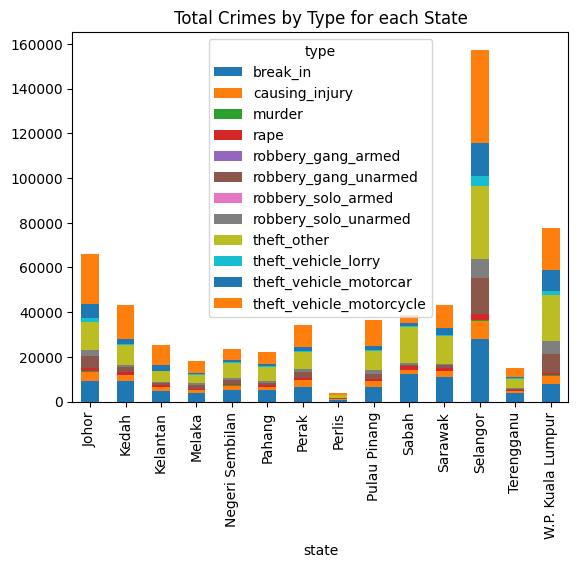

In [ ]:
pivot = crime_df.pivot_table(
    values='crimes',
    index='state',
    columns='type',
    aggfunc='sum'
)

pivot.plot(kind='bar', stacked=True)
plt.title("Total Crimes by Type for each State")
plt.show()

In [ ]:
crime_df.groupby('district')['crimes'].sum().sort_values(ascending=False).head(20)

district
petaling jaya            23078
dang wangi               19980
kajang                   19250
gombak                   19058
sentul                   16456
johor bahru selatan      16022
ampang jaya              15693
wangsa maju              14965
klang selatan            13850
melaka tengah            13765
ipoh                     13088
kuala muda               12952
brickfields              12695
seberang perai tengah    12179
serdang                  12014
cheras                   11679
timur laut               10802
kota setar               10476
kota bharu               10379
seri alam                10007
Name: crimes, dtype: int64

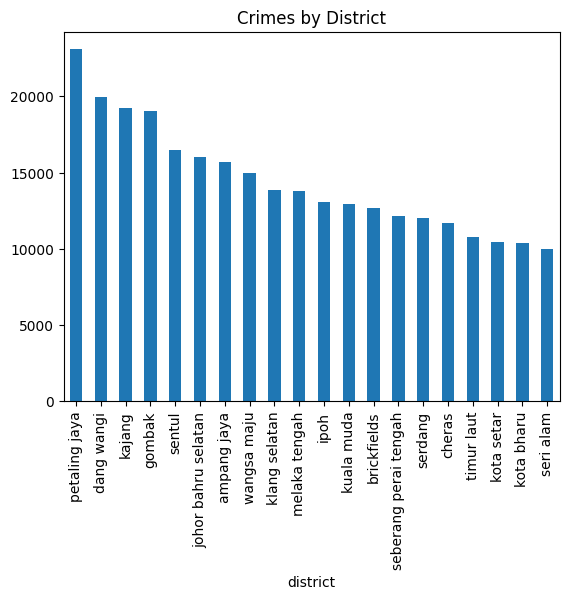

In [ ]:
crime_df.groupby('district')['crimes'].sum().sort_values(ascending=False).head(20).plot(kind='bar')
plt.title("Crimes by District")
plt.show()

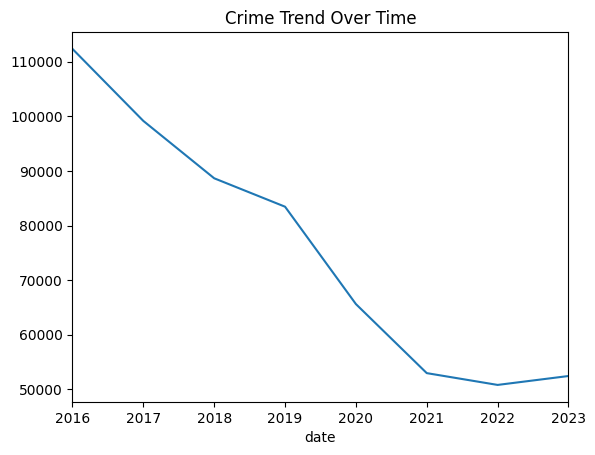

In [ ]:
crime_df.groupby('date')['crimes'].sum().plot()
plt.title("Crime Trend Over Time")
plt.show()

In [ ]:
crime_df.pivot_table(
    values='crimes',
    index='district',
    columns='type',
    aggfunc='sum'
)

type,break_in,causing_injury,murder,rape,robbery_gang_armed,robbery_gang_unarmed,robbery_solo_armed,robbery_solo_unarmed,theft_other,theft_vehicle_lorry,theft_vehicle_motorcar,theft_vehicle_motorcycle
district,,,,,,,,,,,,
alor gajah,518,232,12,88,1,162,0,68,481,30,76,877
ampang jaya,2713,571,31,226,0,1702,1,968,3655,337,1528,3961
arau,195,89,3,73,1,26,0,39,304,2,14,205
bachok,409,237,4,98,0,39,0,29,378,18,105,637
baling,482,166,7,67,0,85,0,52,468,14,88,981
...,...,...,...,...,...,...,...,...,...,...,...,...
tumpat,497,129,6,74,0,92,0,76,461,10,120,711
w.p. labuan,384,71,6,61,1,17,0,15,851,1,6,90
w.p. putrajaya,269,32,3,27,3,484,0,128,504,10,67,399


In [ ]:
crime_df.groupby(['state', 'type'])['crimes'].sum().sort_values(ascending=False).head(20)

state              type                    
Selangor           theft_vehicle_motorcycle    41558
                   theft_other                 32611
                   break_in                    27778
Johor              theft_vehicle_motorcycle    22102
W.P. Kuala Lumpur  theft_other                 20695
                   theft_vehicle_motorcycle    18932
Sabah              theft_other                 16415
Selangor           robbery_gang_unarmed        16205
Kedah              theft_vehicle_motorcycle    15251
Selangor           theft_vehicle_motorcar      15057
Johor              theft_other                 12818
Sarawak            theft_other                 12476
Sabah              break_in                    12473
Pulau Pinang       theft_vehicle_motorcycle    11776
Sarawak            break_in                    10934
                   theft_vehicle_motorcycle    10223
Perak              theft_vehicle_motorcycle     9804
Kedah              break_in                     9357
W.

### 4. Feature Engineering

In [ ]:
y = log1p(crimes)
print(y)